# Error Rate

This notebook is focused on looking at the uncertainty in predictions for the models as well as the absolute error and seeing if there exists a link between the two. 

In [2]:
# Get project root for file paths
from pathlib import Path

notebook_path = Path().resolve()
project_root = notebook_path.parent
data_dir = project_root / "data"
plots_dir = project_root / "output" / "notebook_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

In [3]:
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# Function to load a prediction csv and generate two scatter plots of ensemble standard deviation against both the ensemble residual and absolute ensemble residual
def generate_prediction_plots(prediction_csv_path: str, plot_title: str):
    # Load df
    prediction_df = pd.read_csv(prediction_csv_path)
    # Generate a new column giving the standard deviation of the ten ensemble predictions to give some degree of uncertainty
    # as well as another column with the absolute error between targets and predictions
    # and a third column of the absolute difference

    prediction_df["std_ensemble_preds"] = prediction_df.filter(like='test_preds_seed_').std(axis=1)
    prediction_df["ensemble_residual"] = prediction_df["test_targets"] - prediction_df["test_preds_ensemble"]
    prediction_df["ensemble_residual_absolute"] = (prediction_df["test_targets"] - prediction_df["test_preds_ensemble"]).abs()
    
    # Compute pearson and kendalls tau with p-values
    # rho, p_val_pearson = stats.pearsonr(x=prediction_df["std_ensemble_preds"], y = prediction_df["ensemble_residual"])
    # tau, p_val_kendall = stats.kendalltau(x=prediction_df["std_ensemble_preds"], y = prediction_df["ensemble_residual"])

    # print(f"For std ensemble vs residuals we have pearson: {rho} with p value: {p_val_pearson}, kendalls tau: {tau} with p value: {p_val_kendall}")

    fig = plt.figure(figsize=(10,6))
    sns.scatterplot(data=prediction_df, x='std_ensemble_preds', y='ensemble_residual')
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    plt.title(f"{plot_title}, residuals against ensemble std")
    
    img_path = plots_dir / f"{plot_title}_scatter_residuals_against_std.png" 
    fig.savefig(fname=img_path, bbox_inches="tight")
    plt.show()
    
    # Compute pearson and kendalls tau with p-values
    rho, p_val_pearson = stats.pearsonr(x=prediction_df["std_ensemble_preds"], y = prediction_df["ensemble_residual_absolute"])
    tau, p_val_kendall = stats.kendalltau(x=prediction_df["std_ensemble_preds"], y = prediction_df["ensemble_residual_absolute"])

    print(f"For std ensemble vs absolute residuals we have pearson: {rho:.4f} with p value: {p_val_pearson:.4f}, kendalls tau: {tau:.4f} with p value: {p_val_kendall:.4f}")

    fig = plt.figure(figsize=(10,6))
    sns.scatterplot(data=prediction_df, x='std_ensemble_preds', y ='ensemble_residual_absolute')
    plt.title(f"{plot_title}, absolute residuals against ensemble std, rho={rho:.2f} p value: {p_val_pearson:.4f}, tau={tau:.2f}, p value: {p_val_kendall:.4f}") 
    img_path = plots_dir / f"{plot_title}_scatter_abs_residuals_against_std.png"
    fig.savefig(fname=img_path, bbox_inches="tight") 
    plt.show()


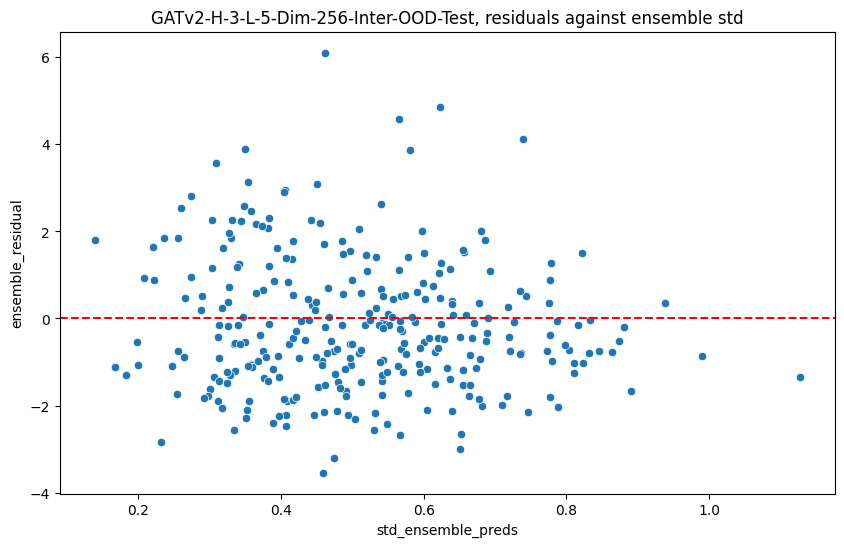

For std ensemble vs absolute residuals we have pearson: -0.1700 with p value: 0.0034, kendalls tau: -0.1401 with p value: 0.0003


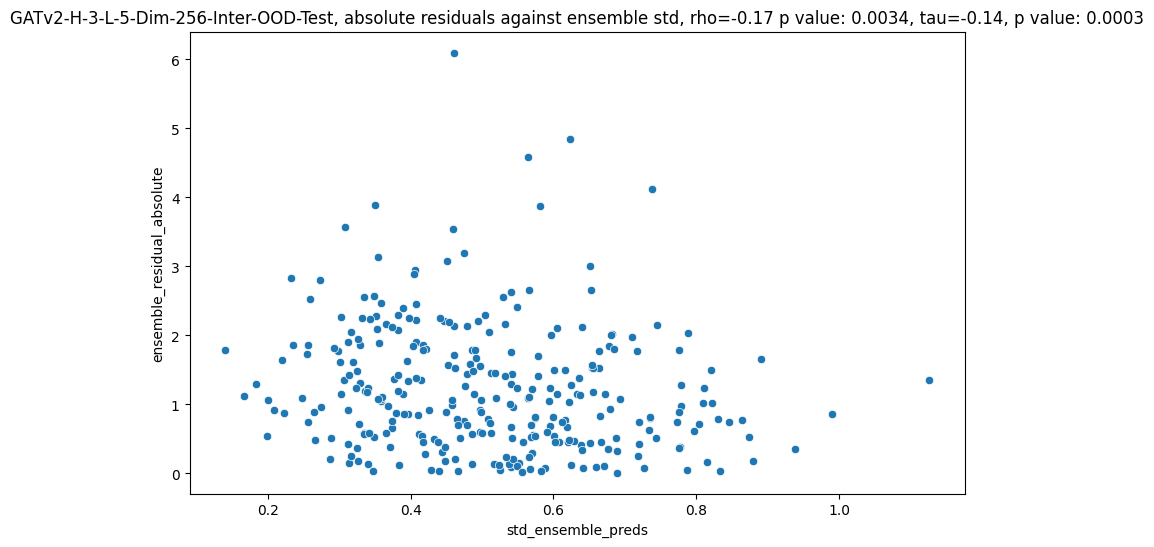

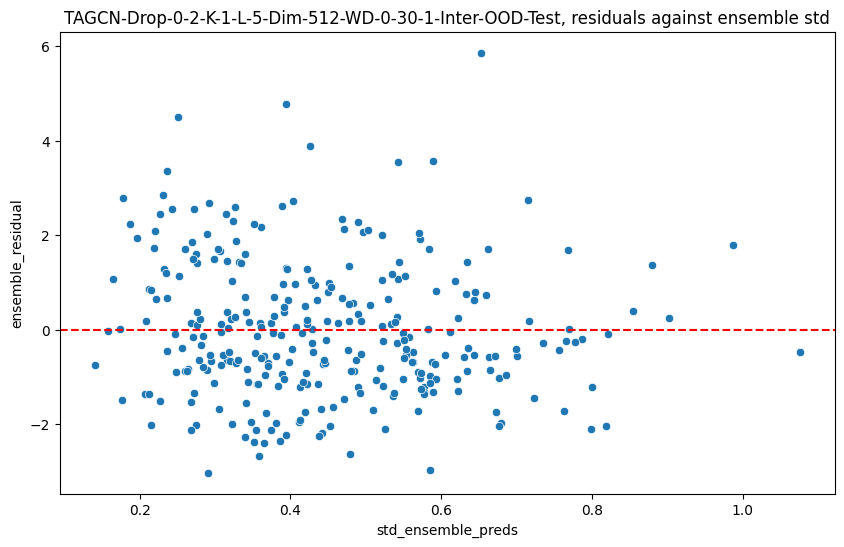

For std ensemble vs absolute residuals we have pearson: -0.0988 with p value: 0.0904, kendalls tau: -0.0726 with p value: 0.0631


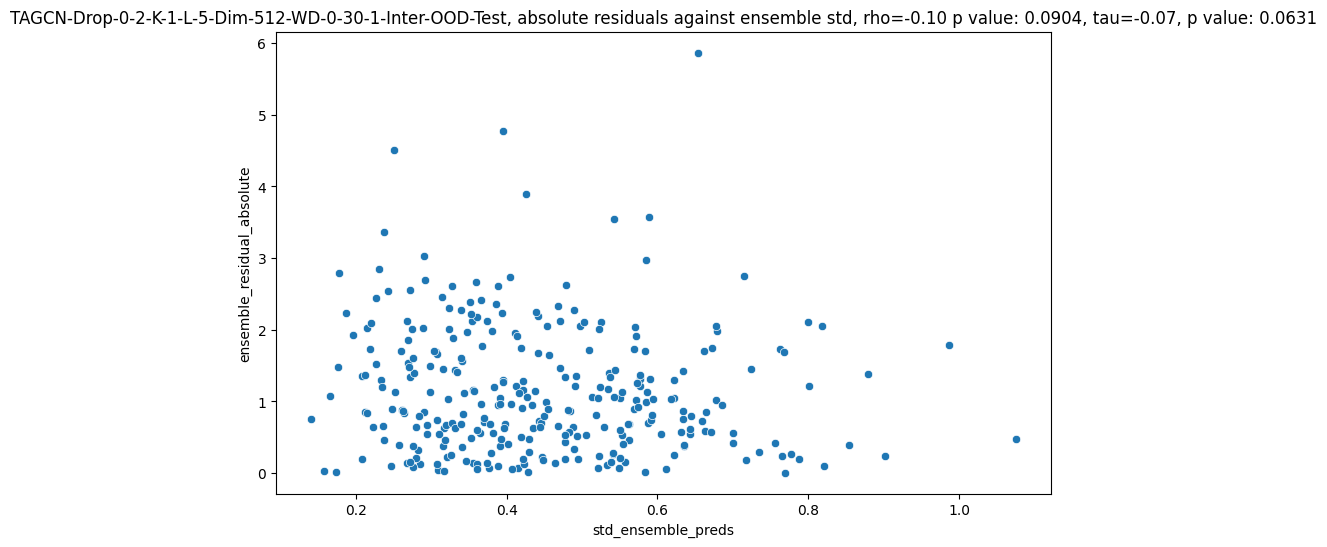

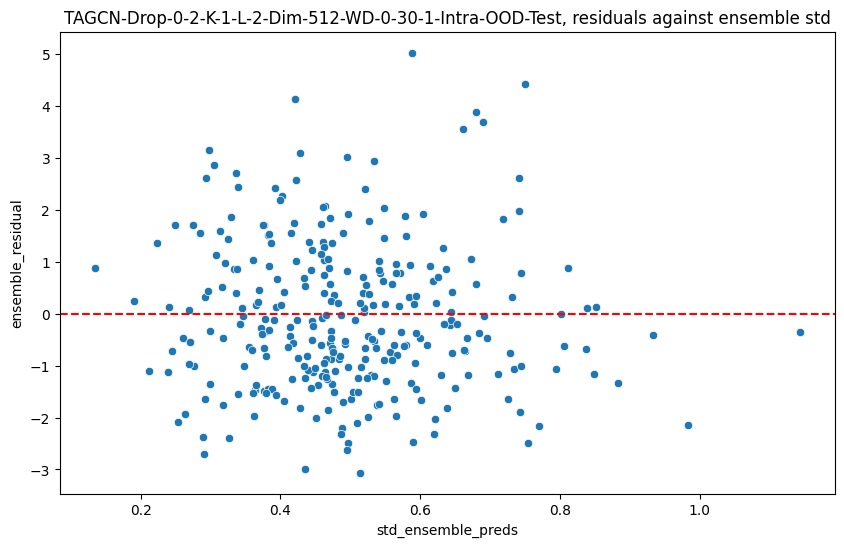

For std ensemble vs absolute residuals we have pearson: -0.0166 with p value: 0.7769, kendalls tau: -0.0421 with p value: 0.2811


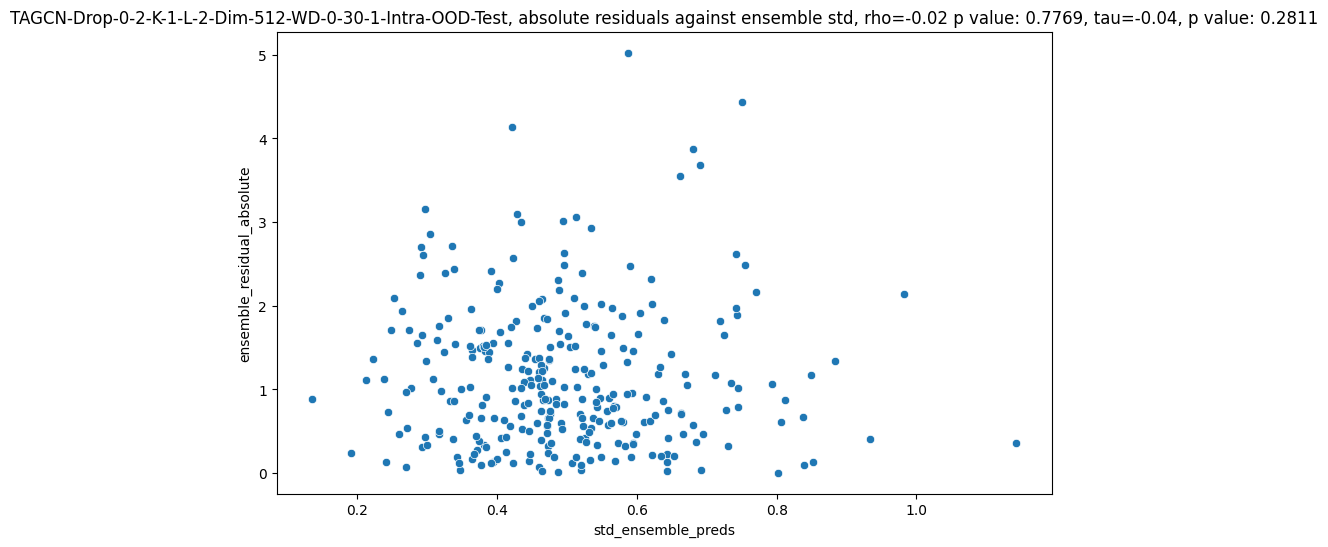

In [4]:
# Load one of the prediction csvs 
prediction_csv_path = data_dir / "predictions" /  "20260308_185500_GATv2-H-3-L-5-Dim-256-Inter-OOD-Test_predictions.csv"
plot_title = "GATv2-H-3-L-5-Dim-256-Inter-OOD-Test"
generate_prediction_plots(prediction_csv_path=prediction_csv_path, plot_title=plot_title)

prediction_csv_path = data_dir / "predictions" / "20260308_185500_TAGCN-Drop-0-2-K-1-L-5-Dim-512-WD-0-30-1-Inter-OOD-Test_predictions.csv"
plot_title = "TAGCN-Drop-0-2-K-1-L-5-Dim-512-WD-0-30-1-Inter-OOD-Test" 
generate_prediction_plots(prediction_csv_path=prediction_csv_path, plot_title=plot_title)

prediction_csv_path = data_dir / "predictions" / "20260310_200900_TAGCN-Drop-0-2-K-1-L-2-Dim-512-WD-0-30-1-Intra-OOD-Test_predictions.csv"
plot_title = "TAGCN-Drop-0-2-K-1-L-2-Dim-512-WD-0-30-1-Intra-OOD-Test" 
generate_prediction_plots(prediction_csv_path=prediction_csv_path, plot_title=plot_title)

